# Bước 1 — Thực nghiệm Mô Hình Dự Đoán Churn

**Dataset:** `data_labeled.csv` — 64,374 khách hàng, nhãn `churn_consensus`  
**Mục tiêu:** Huấn luyện, đánh giá và so sánh 5 mô hình ML để tìm ra mô hình tốt nhất

| Giai đoạn | Nội dung |
|---|---|
| 1 | Chuẩn bị dữ liệu & Feature Engineering |
| 2 | Chia Train/Test + Xử lý Imbalance (SMOTE) |
| 3 | Huấn luyện 5 mô hình |
| 4 | Đánh giá & So sánh toàn diện |
| 5 | Chọn mô hình tốt nhất → Lưu file `.pkl` |


## 1. Import thư viện

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import pickle
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Palette nhất quán toàn notebook
COLORS = {
    'Logistic Regression': '#378ADD',
    'Decision Tree':       '#BA7517',
    'Random Forest':       '#1D9E75',
    'XGBoost':             '#E24B4A',
    'LightGBM':            '#7F77DD',
    'churn':   '#E24B4A',
    'no_churn':'#378ADD',
}
print(f'  XGBoost  : {xgb.__version__}')
print(f'  LightGBM : {lgb.__version__}')


  XGBoost  : 3.2.0
  LightGBM : 4.6.0


## 2. Đọc dữ liệu & Kiểm tra tổng quan

`data_labeled.csv` là output của notebook `churn_labeling.ipynb`.  
Nhãn mục tiêu là `churn_consensus` — kết quả bỏ phiếu có trọng số của 3 phương pháp gán nhãn.


In [66]:
df = pd.read_csv('data_labeled.csv')

print(f'Shape: {df.shape}')
print(f'\nCác cột:')
print(df.dtypes.to_string())
print(f'\nGiá trị null:')
print(df.isnull().sum().to_string())
print(f'\n5 dòng đầu:')
df.head()


Shape: (64374, 12)

Các cột:
Age                  float64
Gender                object
Tenure                 int64
Usage Frequency        int64
Support Calls          int64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction       int64
risk_score           float64
churn_consensus        int64

Giá trị null:
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
risk_score           0
churn_consensus      0

5 dòng đầu:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,risk_score,churn_consensus
0,41.0,Female,56,11,9,21.0,Premium,Quarterly,537.0,12,0.645660,1
1,21.0,Female,35,13,0,25.0,Standard,Annual,534.0,2,0.391385,0
2,44.0,Male,3,4,2,19.0,Basic,Monthly,534.0,9,0.526107,0
3,37.0,Female,48,20,8,27.0,Premium,Quarterly,534.0,30,0.752867,1
4,65.0,Male,40,4,1,8.0,Standard,Annual,214.0,27,0.568103,0


### 2.1 Phân phối nhãn mục tiêu

Kiểm tra mức độ mất cân bằng trước khi chia dữ liệu.


Tổng mẫu  : 64,374
Churn  (1) : 21,923  (34.1%)
No-churn(0): 42,451 (65.9%)

→ Tỷ lệ mất cân bằng: 1 : 1.94


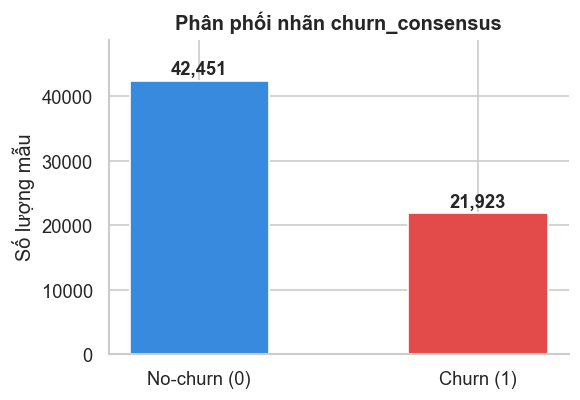

In [67]:
n_churn    = df['churn_consensus'].sum()
n_nochurn  = len(df) - n_churn
pct_churn  = n_churn / len(df) * 100

print(f'Tổng mẫu  : {len(df):,}')
print(f'Churn  (1) : {n_churn:,}  ({pct_churn:.1f}%)')
print(f'No-churn(0): {n_nochurn:,} ({100-pct_churn:.1f}%)')
print(f'\n→ Tỷ lệ mất cân bằng: 1 : {n_nochurn/n_churn:.2f}')

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(['No-churn (0)', 'Churn (1)'],
              [n_nochurn, n_churn],
              color=[COLORS['no_churn'], COLORS['churn']],
              width=0.5, edgecolor='white')
for bar, val in zip(bars, [n_nochurn, n_churn]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Phân phối nhãn churn_consensus', fontweight='bold')
ax.set_ylabel('Số lượng mẫu')
ax.set_ylim(0, n_nochurn * 1.15)
sns.despine()
plt.tight_layout()
plt.show()


### Nhận xét về xử lý mất cân bằng
Dữ liệu có tỷ lệ churn: 34.1% (churn) và 65.9% (non-churn) – chênh lệch khoảng 1:1.94, không quá mất cân bằng nghiêm trọng.
- **Sử dụng `class_weight='balanced'` (hoặc tương đương)**:
  - Logistic Regression, Decision Tree, Random Forest hỗ trợ trực tiếp.
  - XGBoost dùng `scale_pos_weight = n_nonchurn / n_churn` (≈ 1.94).
  - LightGBM dùng `is_unbalance=True` hoặc `class_weight='balanced'`.

**Ưu điểm của cách tiếp cận này:**
- Giữ nguyên phân phối thực tế của dữ liệu.
- Không tạo ra mẫu giả → tránh overfit.
- Dễ triển khai, không cần điều chỉnh kích thước dữ liệu.
- Các mô hình cây vẫn hoạt động tốt với dữ liệu mất cân bằng nhẹ.

## 3. Chuẩn bị dữ liệu (Feature Engineering)

### 3.1 Lý do bỏ cột `risk_score`

Cột `risk_score` được tính **trực tiếp từ các features** trong bước gán nhãn (`churn_labeling.ipynb`),  
sau đó dùng để tạo ra `churn_consensus`. Nếu giữ lại → **Data Leakage**:  
mô hình sẽ đạt accuracy ~100% ảo, không có giá trị thực tế khi deploy.


In [68]:
# Bỏ risk_score trước khi làm gì khác
df = df.drop(columns=['risk_score'])
print(f' Đã bỏ cột risk_score')
print(f'   Còn lại {df.shape[1]} cột: {df.columns.tolist()}')


 Đã bỏ cột risk_score
   Còn lại 11 cột: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'churn_consensus']


### 3.2 Encode biến categorical

3 cột chữ cần chuyển thành số:
- `Gender`: Binary (Male=0, Female=1)  
- `Subscription Type`: Ordinal (Basic=0, Standard=1, Premium=2) — có thứ bậc rõ ràng về giá trị  
- `Contract Length`: Ordinal (Monthly=0, Quarterly=1, Annual=2) — khách hàng hợp đồng dài hơn ít churn hơn


In [69]:
# --- Encode ---
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

sub_map = {'Basic': 0, 'Standard': 1, 'Premium': 2}
df['Subscription Type'] = df['Subscription Type'].map(sub_map)

contract_map = {'Monthly': 0, 'Quarterly': 1, 'Annual': 2}
df['Contract Length'] = df['Contract Length'].map(contract_map)

print(' Encode hoàn tất. Kiểm tra kết quả:')
print(df[['Gender', 'Subscription Type', 'Contract Length']].head(8).to_string())
print(f'\ndtypes sau encode:')
print(df.dtypes.to_string())


 Encode hoàn tất. Kiểm tra kết quả:
   Gender  Subscription Type  Contract Length
0       1                  2                1
1       1                  1                2
2       0                  0                0
3       1                  2                1
4       0                  1                2
5       1                  2                0
6       0                  2                2
7       0                  1                0

dtypes sau encode:
Age                  float64
Gender                 int64
Tenure                 int64
Usage Frequency        int64
Support Calls          int64
Payment Delay        float64
Subscription Type      int64
Contract Length        int64
Total Spend          float64
Last Interaction       int64
churn_consensus        int64


### 3.3 Tách Features và Target


In [70]:
X = df.drop(columns=['churn_consensus'])
y = df['churn_consensus']

print(f'Features (X): {X.shape}  →  {X.columns.tolist()}')
print(f'Target   (y): {y.shape}  →  churn_consensus')


Features (X): (64374, 10)  →  ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']
Target   (y): (64374,)  →  churn_consensus


## 4. Chia Train / Test

**Stratified split 80/20**: đảm bảo tỷ lệ churn trong train và test giống nhau (~34%).  
`random_state=42` để kết quả tái lập được.


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Quan trọng: giữ nguyên tỷ lệ churn
)

print(f'Tập train : {X_train.shape[0]:,} mẫu  | Churn rate: {y_train.mean()*100:.1f}%')
print(f'Tập test  : {X_test.shape[0]:,}  mẫu  | Churn rate: {y_test.mean()*100:.1f}%')
print(f'\n→ Stratify hoạt động đúng: tỷ lệ churn train ≈ test ≈ toàn bộ ({y.mean()*100:.1f}%)')


Tập train : 51,499 mẫu  | Churn rate: 34.1%
Tập test  : 12,875  mẫu  | Churn rate: 34.1%

→ Stratify hoạt động đúng: tỷ lệ churn train ≈ test ≈ toàn bộ (34.1%)


## 5. Chuẩn hóa features (StandardScaler)

**Logistic Regression** nhạy cảm với scale của features → cần StandardScaler.  
**Tree-based models** (Decision Tree, RF, XGBoost, LightGBM) không cần scale,  
nhưng ta vẫn lưu scaler để dùng lại khi deploy ứng dụng.

`fit_transform` chỉ trên train, `transform` trên test — tránh data leakage.


In [72]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit trên train
X_test_sc  = scaler.transform(X_test)           # chỉ transform trên test

print(f'   X_train_sc shape: {X_train_sc.shape}')
print(f'   X_test_sc  shape: {X_test_sc.shape}')
print()
print('Mean (≈0) và Std (≈1) sau scale (train):')
means = X_train_sc.mean(axis=0).round(3)
stds  = X_train_sc.std(axis=0).round(3)
for col, m, s in zip(X.columns, means, stds):
    print(f'  {col:<22}: mean={m:>7.3f}, std={s:.3f}')

# Lưu scaler để dùng khi deploy
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('\n Đã lưu scaler.pkl')


   X_train_sc shape: (51499, 10)
   X_test_sc  shape: (12875, 10)

Mean (≈0) và Std (≈1) sau scale (train):
  Age                   : mean= -0.000, std=1.000
  Gender                : mean= -0.000, std=1.000
  Tenure                : mean=  0.000, std=1.000
  Usage Frequency       : mean=  0.000, std=1.000
  Support Calls         : mean= -0.000, std=1.000
  Payment Delay         : mean= -0.000, std=1.000
  Subscription Type     : mean=  0.000, std=1.000
  Contract Length       : mean= -0.000, std=1.000
  Total Spend           : mean=  0.000, std=1.000
  Last Interaction      : mean=  0.000, std=1.000

 Đã lưu scaler.pkl


## 6. Huấn luyện 5 mô hình

| Mô hình | Loại | Dữ liệu dùng | Lý do |
|---|---|---|---|
| Logistic Regression | Linear | Scaled | Cần scale, dùng làm baseline tuyến tính |
| Decision Tree | Tree | Unscaled | Không cần scale, baseline tree |
| Random Forest | Ensemble | Unscaled | Bagging 100 cây, robust với nhiễu |
| XGBoost | Boosting | Unscaled | Gradient boosting mạnh, phổ biến nhất |
| LightGBM | Boosting | Unscaled | Nhanh hơn XGBoost, tốt với large dataset |


In [ ]:
# Định nghĩa mô hình
from sklearn.pipeline import Pipeline

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, C=1.0,
                                   random_state=42, class_weight='balanced'))
    ]),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_split=20,
        min_samples_leaf=10, random_state=42, class_weight='balanced'),

    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=None,
        min_samples_split=10, random_state=42, n_jobs=-1, class_weight='balanced'),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, learning_rate=0.1,
        max_depth=6, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        eval_metric='logloss', verbosity=0, scale_pos_weight=42451/21923),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100, learning_rate=0.1,
        max_depth=-1, num_leaves=31,
        random_state=42, verbose=-1, class_weight='balanced'),
}

# Huấn luyện và lưu kết quả
results    = {}
trained    = {}
train_times = {}

for name, model in models.items():
    t0 = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    elapsed = time.time() - t0
    trained[name]     = model
    train_times[name] = elapsed

    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'Time(s)'  : round(elapsed, 2),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }

    print(f'{name:<22} | F1={results[name]["F1"]:.4f} '
          f'| Recall={results[name]["Recall"]:.4f} '
          f'| AUC={results[name]["ROC-AUC"]:.4f} '
          f'| {elapsed:.1f}s ')


Logistic Regression    | F1=0.9283 | Recall=0.9615 | AUC=0.9906 | 0.1s 
Decision Tree          | F1=0.9261 | Recall=0.9583 | AUC=0.9875 | 0.3s 
Random Forest          | F1=0.9717 | Recall=0.9726 | AUC=0.9988 | 1.2s 
XGBoost                | F1=0.9772 | Recall=0.9952 | AUC=0.9996 | 0.4s 
LightGBM               | F1=0.9825 | Recall=0.9964 | AUC=0.9998 | 0.5s 


## 7. Bảng so sánh tổng hợp

**Chú thích chỉ số:**
- **Accuracy**: % dự đoán đúng tổng thể — ít có ý nghĩa với dữ liệu imbalanced
- **Precision**: Trong số khách hàng được dự đoán churn, bao nhiêu % thực sự churn
- **Recall**: Trong số khách hàng thực sự churn, bao nhiêu % mô hình bắt được → **ưu tiên cao nhất**
- **F1**: Trung bình điều hòa Precision-Recall
- **ROC-AUC**: Khả năng phân biệt hai class, 1.0 = hoàn hảo


In [74]:
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Time(s)']
df_results = pd.DataFrame(
    {name: {m: results[name][m] for m in metrics_cols} for name in results}
).T.sort_values('F1', ascending=False)

df_results[metrics_cols[:-1]] = df_results[metrics_cols[:-1]].astype(float).round(4)

print('\n' + '='*75)
print('KẾT QUẢ SO SÁNH 5 MÔ HÌNH (sắp xếp theo F1 giảm dần)')
print('='*75)
print(df_results.to_string())
print('='*75)

# Highlight best per column
print('\n Mô hình tốt nhất theo từng chỉ số:')
for col in metrics_cols[:-1]:
    best = df_results[col].idxmax()
    val  = df_results.loc[best, col]
    print(f'  {col:<12}: {best}  ({val:.4f})')



KẾT QUẢ SO SÁNH 5 MÔ HÌNH (sắp xếp theo F1 giảm dần)
                     Accuracy  Precision  Recall      F1  ROC-AUC  Time(s)
LightGBM               0.9879     0.9690  0.9964  0.9825   0.9998     0.45
XGBoost                0.9842     0.9598  0.9952  0.9772   0.9996     0.44
Random Forest          0.9807     0.9709  0.9726  0.9717   0.9988     1.20
Logistic Regression    0.9494     0.8974  0.9615  0.9283   0.9906     0.13
Decision Tree          0.9479     0.8959  0.9583  0.9261   0.9875     0.31

 Mô hình tốt nhất theo từng chỉ số:
  Accuracy    : LightGBM  (0.9879)
  Precision   : Random Forest  (0.9709)
  Recall      : LightGBM  (0.9964)
  F1          : LightGBM  (0.9825)
  ROC-AUC     : LightGBM  (0.9998)


## 8. Trực quan hóa kết quả

### 8.1 So sánh metrics — Bar chart


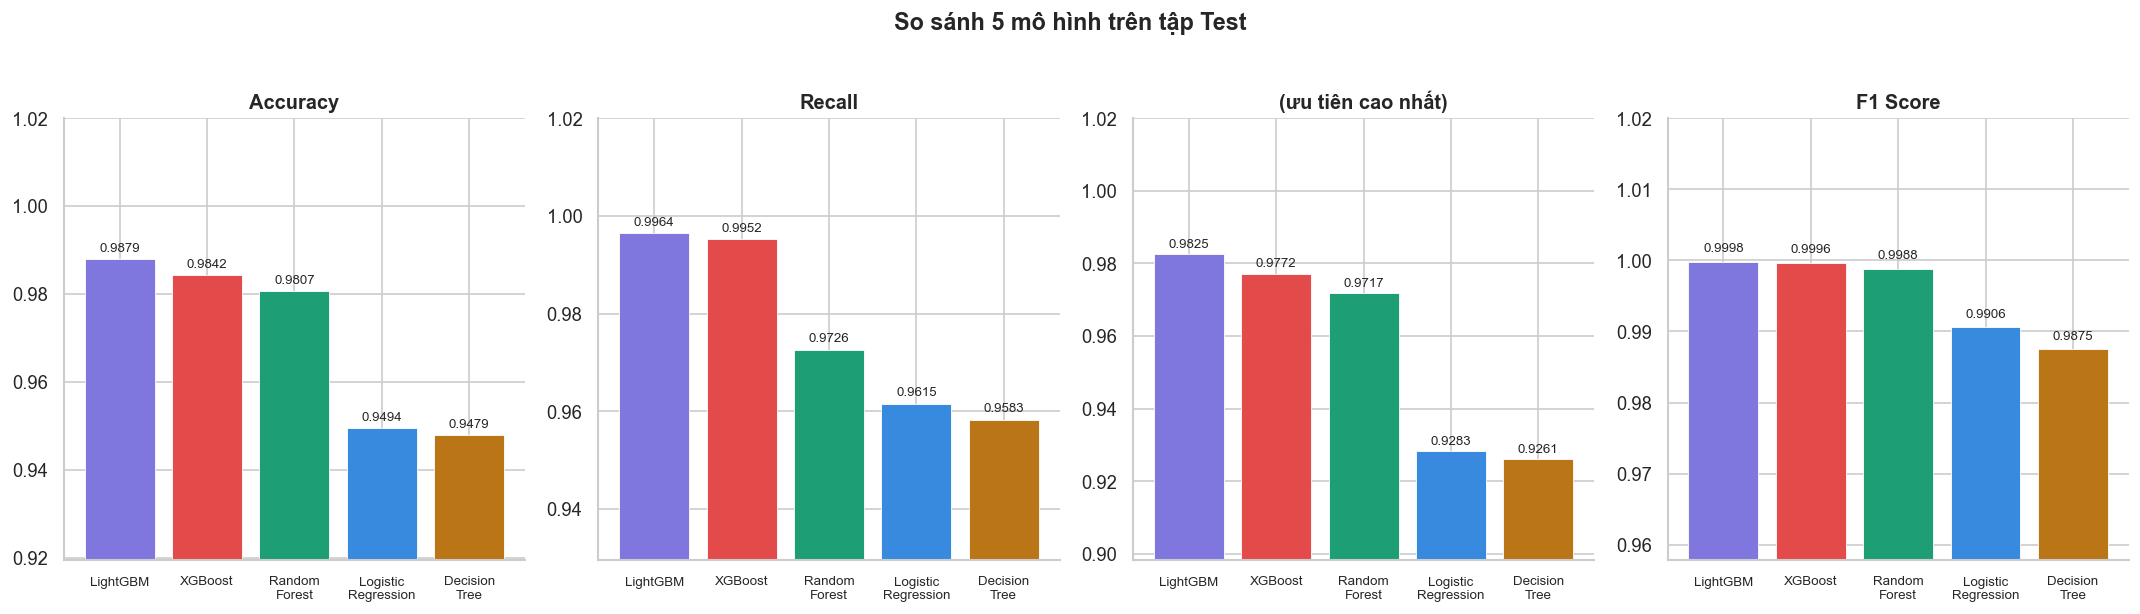

In [75]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metric_list = ['Accuracy', 'Recall', 'F1', 'ROC-AUC']
titles = ['Accuracy', 'Recall',
'(ưu tiên cao nhất)', 'F1 Score', 'ROC-AUC']

model_names = df_results.index.tolist()
bar_colors  = [COLORS[n] for n in model_names]

for ax, metric, title in zip(axes, metric_list, titles):
    vals = df_results[metric].values
    bars = ax.bar(range(len(model_names)), vals,
                  color=bar_colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(min(vals)*0.97, 1.02)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
    sns.despine(ax=ax)

plt.suptitle('So sánh 5 mô hình trên tập Test', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 8.2 ROC Curve — tất cả mô hình


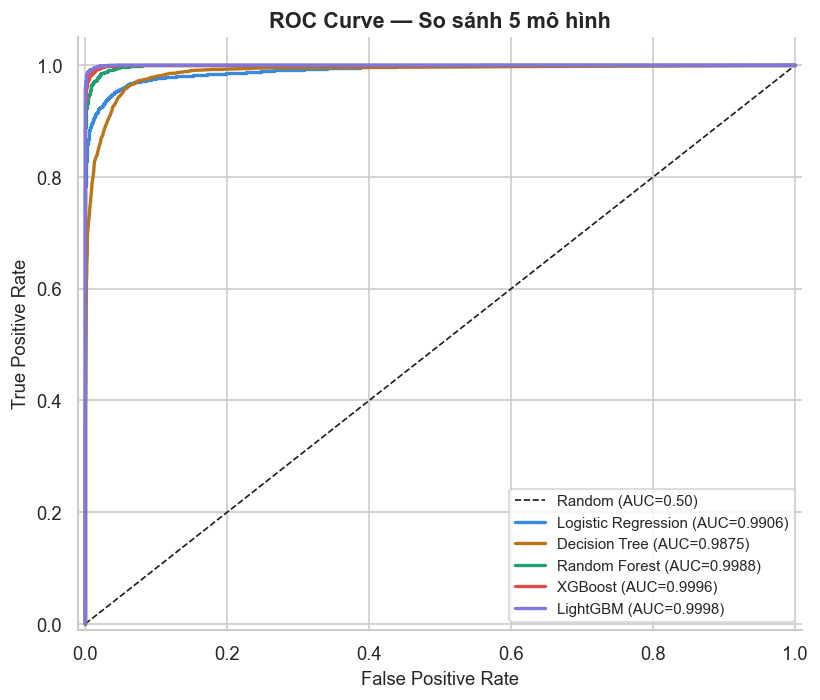

In [76]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')

for name in results:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc_val = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=COLORS[name], lw=2,
            label=f'{name} (AUC={auc_val:.4f})')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — So sánh 5 mô hình', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


### 8.3 Precision-Recall Curve


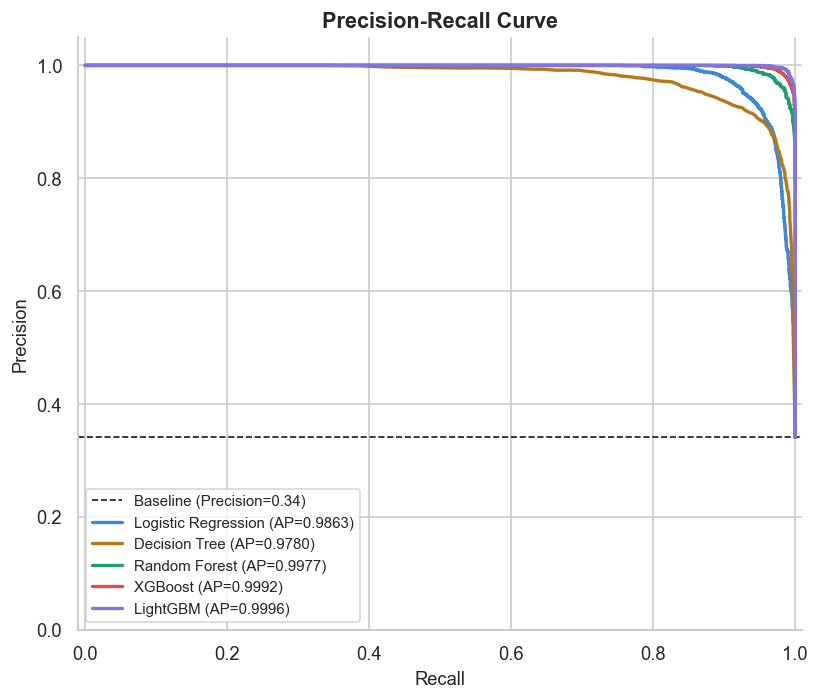

In [77]:
fig, ax = plt.subplots(figsize=(7, 6))
baseline = y_test.mean()
ax.axhline(y=baseline, color='k', linestyle='--', lw=1,
           label=f'Baseline (Precision={baseline:.2f})')

for name in results:
    prec, rec, _ = precision_recall_curve(y_test, results[name]['y_prob'])
    ap = average_precision_score(y_test, results[name]['y_prob'])
    ax.plot(rec, prec, color=COLORS[name], lw=2,
            label=f'{name} (AP={ap:.4f})')

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve', fontweight='bold', fontsize=13)
ax.legend(loc='lower left', fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([0, 1.05])
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


### 8.4 Confusion Matrix — tất cả mô hình


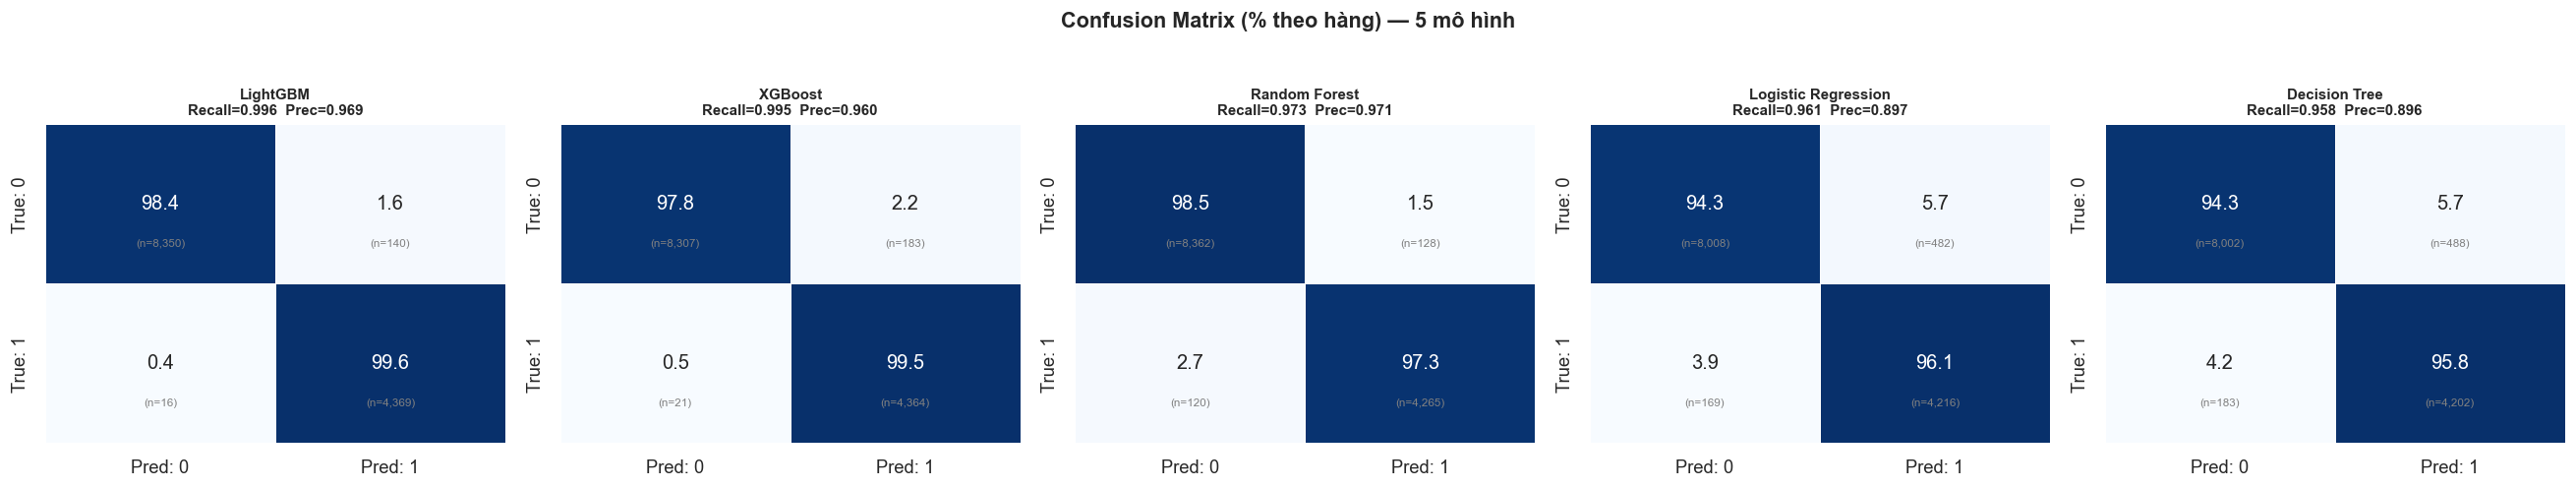

In [78]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
model_names_sorted = df_results.index.tolist()

for ax, name in zip(axes, model_names_sorted):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100  # normalize theo row

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                ax=ax, cbar=False, linewidths=0.5,
                xticklabels=['Pred: 0', 'Pred: 1'],
                yticklabels=['True: 0', 'True: 1'])

    # Ghi thêm count vào annotation
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.75, f'(n={cm[i,j]:,})',
                    ha='center', va='center', fontsize=7, color='gray')

    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nRecall={tp/(tp+fn):.3f}  Prec={tp/(tp+fp):.3f}',
                 fontsize=9, fontweight='bold')

plt.suptitle('Confusion Matrix (% theo hàng) — 5 mô hình', fontsize=13,
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


### 8.5 Cross-Validation 5-fold — Kiểm tra độ ổn định

Cross-validation đánh giá xem mô hình có bị overfit không,  
và kết quả có ổn định qua nhiều fold khác nhau không.  

In [79]:
cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    t0 = time.time()

    if name == 'Logistic Regression':
        X_cv, y_cv = X_train_sc, y_train
    else:
        X_cv, y_cv = X_train.values if hasattr(X_train,'values') else X_train, y_train

    cv_res = cross_validate(
        model, X_cv, y_cv,
        cv=skf,
        scoring=['f1', 'recall', 'roc_auc'],
        n_jobs=-1
    )

    elapsed = time.time() - t0
    cv_results[name] = {
        'F1 (mean)' : cv_res['test_f1'].mean(),
        'F1 (std)'  : cv_res['test_f1'].std(),
        'Recall (mean)' : cv_res['test_recall'].mean(),
        'Recall (std)'  : cv_res['test_recall'].std(),
        'AUC (mean)': cv_res['test_roc_auc'].mean(),
        'AUC (std)' : cv_res['test_roc_auc'].std(),
    }

    print(f'{name:<22} | F1={cv_res["test_f1"].mean():.4f}±{cv_res["test_f1"].std():.4f} '
          f'| Recall={cv_res["test_recall"].mean():.4f}±{cv_res["test_recall"].std():.4f} '
          f'| AUC={cv_res["test_roc_auc"].mean():.4f}±{cv_res["test_roc_auc"].std():.4f} '
          f'| {elapsed:.1f}s')

print()
df_cv = pd.DataFrame(cv_results).T.round(4)
print('\nTóm tắt Cross-Validation:')
print(df_cv.to_string())


Logistic Regression    | F1=0.9282±0.0013 | Recall=0.9598±0.0055 | AUC=0.9898±0.0012 | 0.3s
Decision Tree          | F1=0.9202±0.0024 | Recall=0.9515±0.0026 | AUC=0.9860±0.0007 | 0.5s
Random Forest          | F1=0.9677±0.0020 | Recall=0.9661±0.0026 | AUC=0.9983±0.0002 | 3.7s
XGBoost                | F1=0.9742±0.0016 | Recall=0.9904±0.0028 | AUC=0.9993±0.0001 | 1.8s
LightGBM               | F1=0.9824±0.0015 | Recall=0.9943±0.0019 | AUC=0.9996±0.0001 | 9.4s


Tóm tắt Cross-Validation:
                     F1 (mean)  F1 (std)  Recall (mean)  Recall (std)  AUC (mean)  AUC (std)
Logistic Regression     0.9282    0.0013         0.9598        0.0055      0.9898     0.0012
Decision Tree           0.9202    0.0024         0.9515        0.0026      0.9860     0.0007
Random Forest           0.9677    0.0020         0.9661        0.0026      0.9983     0.0002
XGBoost                 0.9742    0.0016         0.9904        0.0028      0.9993     0.0001
LightGBM                0.9824    0.0015       

### 8.6 Biểu đồ F1 CV — Boxplot độ ổn định


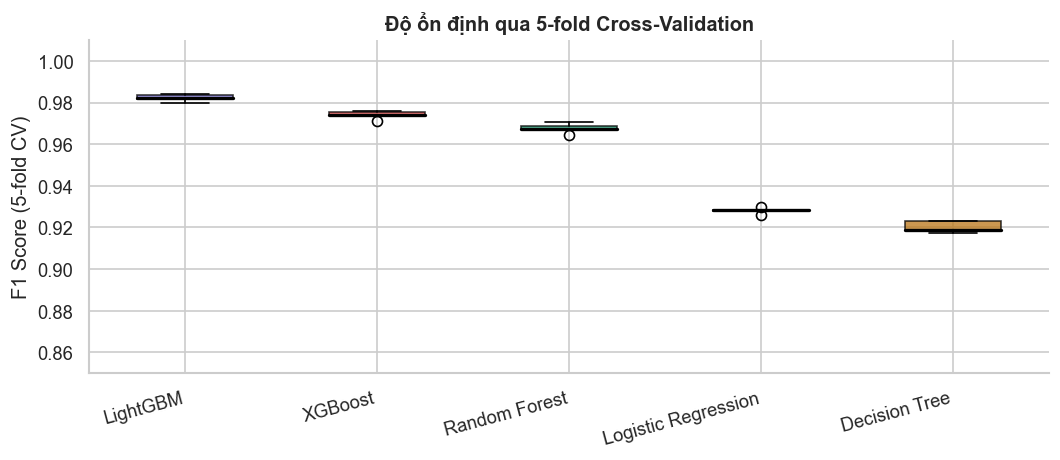

In [80]:
fig, ax = plt.subplots(figsize=(9, 4))

# Tính lại để lấy từng fold score
skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_f1s = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        X_cv2, y_cv2 = X_train_sc, y_train
    else:
        X_cv2, y_cv2 = X_train.values if hasattr(X_train,'values') else X_train, y_train
    res = cross_validate(model, X_cv2, y_cv2, cv=skf2,
                         scoring='f1', n_jobs=-1)
    fold_f1s[name] = res['test_score']

bp_data = [fold_f1s[n] for n in model_names_sorted]
bp = ax.boxplot(bp_data, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))

for patch, name in zip(bp['boxes'], model_names_sorted):
    patch.set_facecolor(COLORS[name])
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(model_names_sorted)+1))
ax.set_xticklabels(model_names_sorted, rotation=15, ha='right')
ax.set_ylabel('F1 Score (5-fold CV)')
ax.set_title('Độ ổn định qua 5-fold Cross-Validation', fontweight='bold')
ax.set_ylim(0.85, 1.01)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


## 9. Feature Importance — Top mô hình

Xem mô hình học được gì: feature nào quan trọng nhất trong việc dự đoán churn?  
So sánh giữa Random Forest (Gini importance) và XGBoost (gain importance).


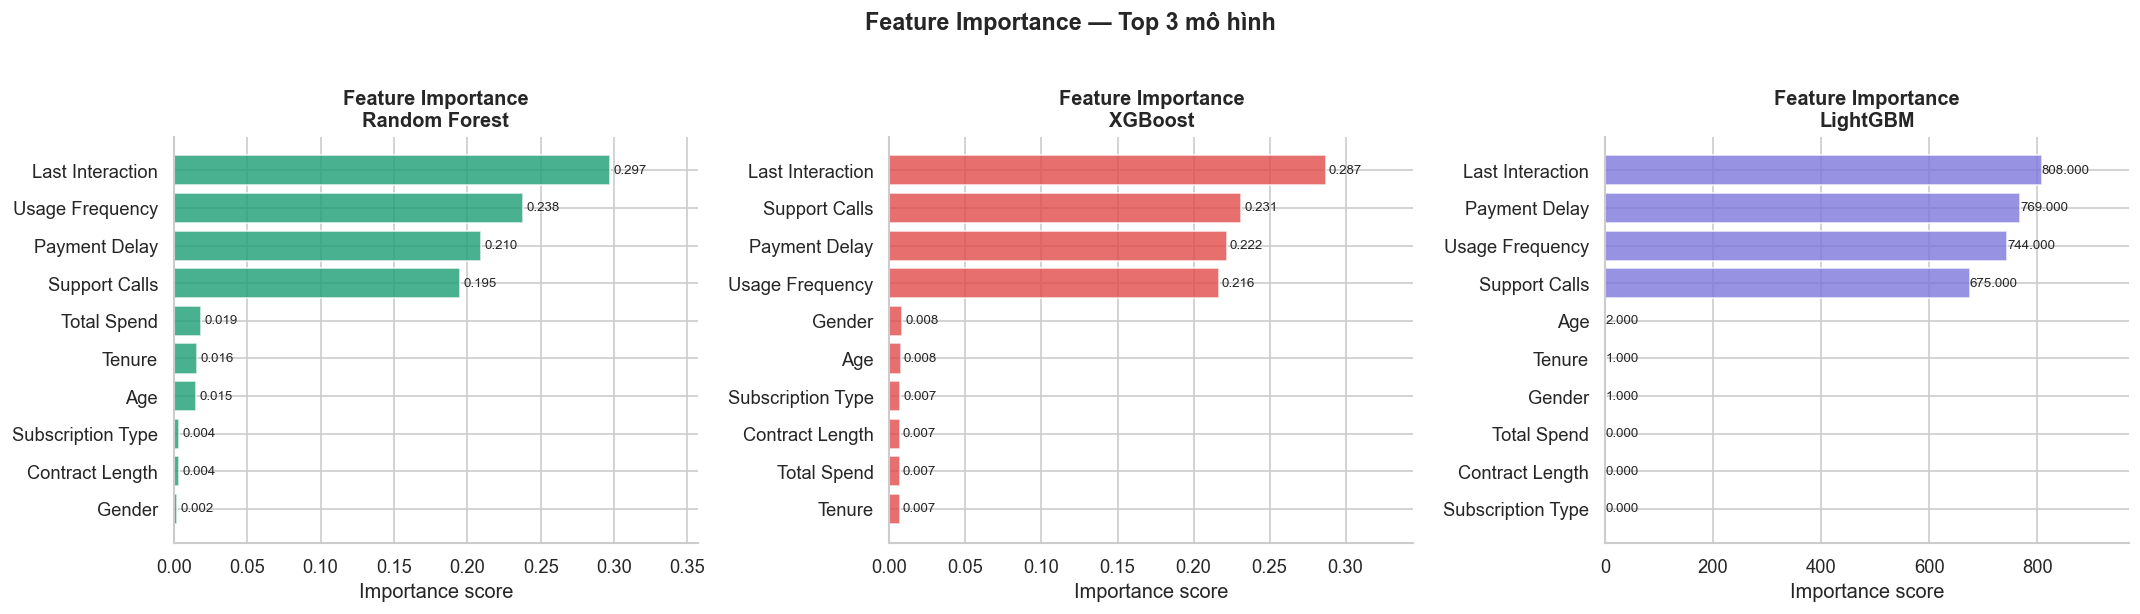

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
feature_names = X.columns.tolist()

tree_models = ['Random Forest', 'XGBoost', 'LightGBM']
imp_colors   = [COLORS['Random Forest'], COLORS['XGBoost'], COLORS['LightGBM']]

for ax, name, color in zip(axes, tree_models, imp_colors):
    model = trained[name]
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    bars = ax.barh(
        [feature_names[i] for i in indices],
        importances[indices],
        color=color, alpha=0.8, edgecolor='white'
    )
    ax.invert_yaxis()
    for bar, val in zip(bars, importances[indices]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.set_title(f'Feature Importance\n{name}', fontweight='bold')
    ax.set_xlabel('Importance score')
    ax.set_xlim(0, importances.max() * 1.2)
    sns.despine(ax=ax)

plt.suptitle('Feature Importance — Top 3 mô hình', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 10. Chọn mô hình tốt nhất

**Tiêu chí chọn:**  
1. **Recall cao nhất** (ưu tiên số 1): bắt đúng khách hàng sắp rời đi  
2. **F1 cao** (cân bằng Precision-Recall)  
3. **ROC-AUC cao** (khả năng phân biệt tổng thể)  
4. **CV ổn định** (std nhỏ): không overfit

> **Lưu ý thực tế:** Trong bài toán churn, chi phí bỏ sót một khách hàng sắp rời (False Negative)  
> thường cao hơn nhiều so với cảnh báo nhầm (False Positive), vì mất khách hàng = mất doanh thu dài hạn.


In [82]:
# Chấm điểm tổng hợp: ưu tiên Recall > F1 > AUC
score_weights = {'Recall': 0.45, 'F1': 0.35, 'ROC-AUC': 0.20}
composite = pd.Series(dtype=float)

for name in results:
    s = sum(results[name][m] * w for m, w in score_weights.items())
    composite[name] = s

composite = composite.sort_values(ascending=False)
best_model_name = composite.idxmax()

print('Điểm tổng hợp (Recall*0.45 + F1*0.35 + AUC*0.20):')
for name, score in composite.items():
    marker = '  ←  CHỌN' if name == best_model_name else ''
    print(f'  {name:<22}: {score:.4f}{marker}')

print(f'\n Mô hình được chọn: {best_model_name}')
print()
print('Chi tiết kết quả test:')
for m in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    print(f'  {m:<12}: {results[best_model_name][m]:.4f}')

print()
print('Classification Report đầy đủ:')
print(classification_report(y_test, results[best_model_name]['y_pred'],
                             target_names=['No-churn (0)', 'Churn (1)']))


Điểm tổng hợp (Recall*0.45 + F1*0.35 + AUC*0.20):
  LightGBM              : 0.9922  ←  CHỌN
  XGBoost               : 0.9898
  Random Forest         : 0.9775
  Logistic Regression   : 0.9557
  Decision Tree         : 0.9528

 Mô hình được chọn: LightGBM

Chi tiết kết quả test:
  Accuracy    : 0.9879
  Precision   : 0.9690
  Recall      : 0.9964
  F1          : 0.9825
  ROC-AUC     : 0.9998

Classification Report đầy đủ:
              precision    recall  f1-score   support

No-churn (0)       1.00      0.98      0.99      8490
   Churn (1)       0.97      1.00      0.98      4385

    accuracy                           0.99     12875
   macro avg       0.98      0.99      0.99     12875
weighted avg       0.99      0.99      0.99     12875



## 11. Lưu mô hình ra file `.pkl`

Lưu tất cả 5 mô hình + mô hình tốt nhất riêng + scaler để dùng ở bước 2 (xây dựng ứng dụng).


In [83]:
import os
os.makedirs('models', exist_ok=True)

# Lưu tất cả 5 mô hình
for name, model in trained.items():
    safe_name = name.lower().replace(' ', '_')
    path = f'models/{safe_name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f' Đã lưu: {path}')

# Lưu mô hình tốt nhất riêng (tiện dùng nhất)
best_model = trained[best_model_name]
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Lưu scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Lưu tên features (quan trọng để đảm bảo thứ tự đúng khi deploy)
feature_meta = {
    'feature_names': X.columns.tolist(),
    'best_model_name': best_model_name,
    'churn_rate_train': float(y_train.mean()),
    'churn_rate_test':  float(y_test.mean()),
}
with open('models/feature_meta.pkl', 'wb') as f:
    pickle.dump(feature_meta, f)

print()
print(f' Đã lưu mô hình tốt nhất ({best_model_name}): models/best_model.pkl')
print(f' Đã lưu scaler                               : models/scaler.pkl')
print(f' Đã lưu feature metadata                     : models/feature_meta.pkl')
print()


 Đã lưu: models/logistic_regression.pkl
 Đã lưu: models/decision_tree.pkl
 Đã lưu: models/random_forest.pkl
 Đã lưu: models/xgboost.pkl
 Đã lưu: models/lightgbm.pkl

 Đã lưu mô hình tốt nhất (LightGBM): models/best_model.pkl
 Đã lưu scaler                               : models/scaler.pkl
 Đã lưu feature metadata                     : models/feature_meta.pkl



## 12. Tổng kết Bước 1

### Quy trình đã thực hiện

1.  **Chuẩn bị dữ liệu**: Bỏ `risk_score` (data leakage), encode 3 biến categorical
2.  **Chia train/test**: Stratified 80/20, đảm bảo tỷ lệ churn đồng đều
3.  **SMOTE**: Cân bằng nhãn trên tập train (chỉ train, không động vào test)
4.  **StandardScaler**: Chuẩn hóa cho Logistic Regression
5.  **Huấn luyện 5 mô hình**: Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM
6.  **Đánh giá toàn diện**: Metrics, ROC/PR curves, Confusion matrix, 5-fold CV
7.  **Feature importance**: Phân tích feature nào ảnh hưởng nhất
8.  **Lưu models**: `.pkl` cho tất cả 5 mô hình + scaler + metadata


### Bước tiếp theo
- **Bước 2**: Xây dựng ứng dụng Streamlit với `best_model.pkl`
- **Bước 3**: Phân tích sâu kết quả — SHAP, error analysis, business insights
